# Project 2 - Classification - Logistic Regression

**In this file:** 
+ Data Preparation + Modeling - Logistic Regression 
 

=== 

**On other files:**
+ Business Understanding + Data Undertanding + Evaluation (of analyzed models).  *File Name:* ML_02_Business..ipynb 
+ Model Decision Trees.  *File Name:* ML_02_Model_DecisionTrees.ipynb
+ Model K-Nearest Neighbor (KNN).  *File Name:* ML_Model_KNN.ipynb
+ Model Logistic Regression.  *File Name:* ML_02_Model_LogisticR.ipynb
+ Models: Support Vector Machine (SVM), Neural networks and Naïve Bayes.  *File Name:* ML_02_Model_SVN_NN_NB.ipynb

===

#### **Group V**
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

In [89]:
#Package loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import pickle

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Data Preparation 

In [90]:
#Load Data
df = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_02/campaign.xlsx')
print(f'Shape: {df.shape}')
df.describe(include='all').T

Shape: (2240, 29)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,665,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2237.0,NaN,NaN,NaN,303.838623,336.576209,0.0,24.0,173.0,504.0,1493.0


In [91]:
#Create a data copy 
df_prep = df.copy()

#### Missing Values

In [92]:
#Check missing values
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

Income          24
MntWines         3
MntFruits        2
MntGoldProds    53
dtype: int64


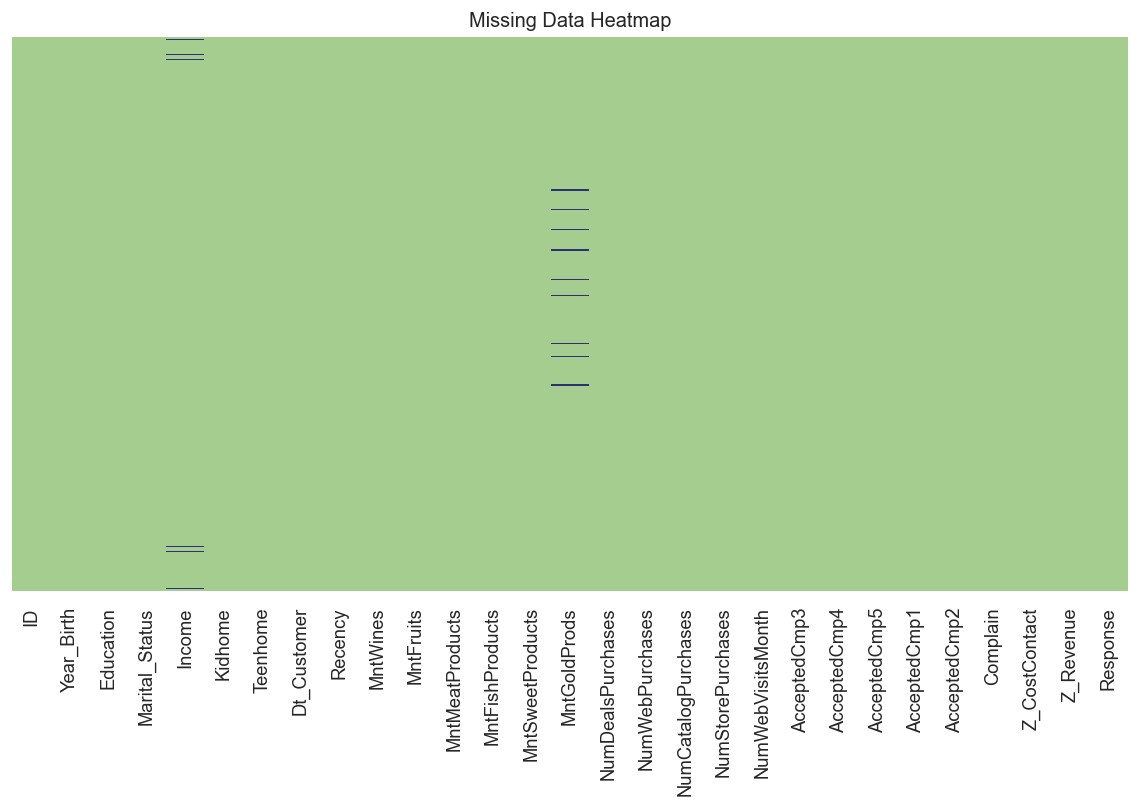

In [93]:
#Heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_prep.isnull(), yticklabels=False, cbar=False, cmap='crest')
plt.title('Missing Data Heatmap')
plt.show()

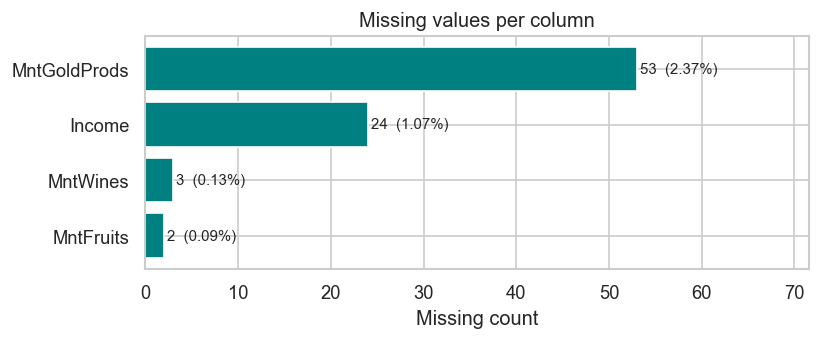

In [94]:
missing = df_prep.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing.index, missing.values, color='teal')

for bar, count, p in zip(bars, missing.values, pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{count}  ({p}%)', va='center', fontsize=9)

ax.set_xlabel('Missing count')
ax.set_title('Missing values per column')
ax.set_xlim(0, missing.max() * 1.35)
plt.tight_layout()
plt.show()

Observations: 
Missing values on Income, MntGoldProds, MntWines and MntFruits. 
MntWines and MntFruits change with median. 
Check Income and MntGoldProds - Possible use k-means to replace missing information

#### MntWines and MntFruits Values

In [95]:
#Impute MntWines and MntFruits missing values with median
for col in ['MntWines', 'MntFruits']:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

In [96]:
remaining_missing = df_prep.isnull().sum()
print(remaining_missing[remaining_missing > 0])

Income          24
MntGoldProds    53
dtype: int64


#### Gold Products

In [97]:
display(df_prep['MntGoldProds'].describe())

count    2187.000000
mean       44.596251
std        52.419487
min         0.000000
25%         9.000000
50%        25.000000
75%        57.000000
max       362.000000
Name: MntGoldProds, dtype: float64

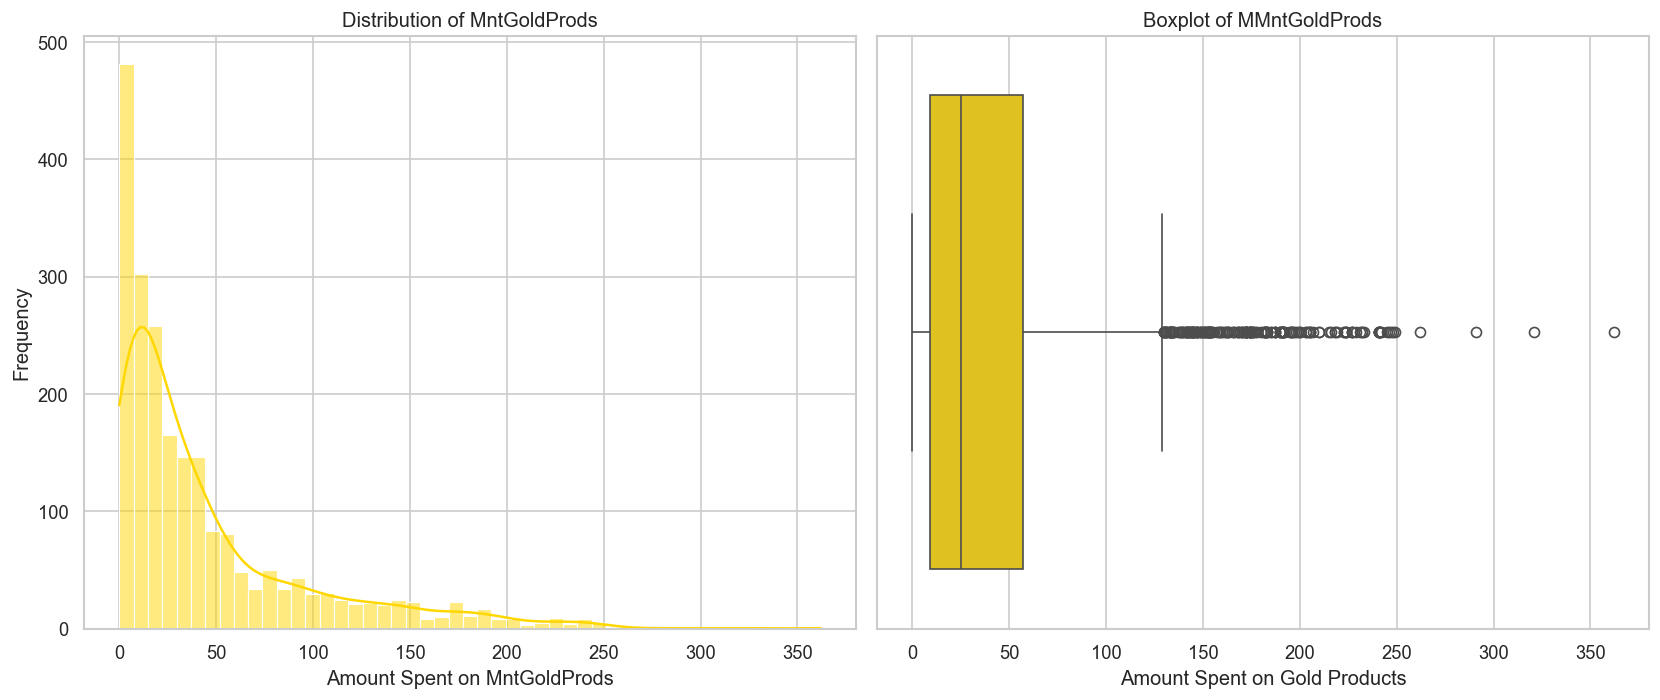

In [98]:
#Check MntGoldProds distribution 

# Visualize MntGoldProds
sns.set_theme(style="whitegrid")

# Create a figure with a Histogram and a Boxplot
plt.figure(figsize=(14, 6))

#Histogram 
plt.subplot(1, 2, 1)
sns.histplot(df_prep['MntGoldProds'], kde=True, color='gold')
plt.title('Distribution of MntGoldProds')
plt.xlabel('Amount Spent on MntGoldProds')
plt.ylabel('Frequency')

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_prep['MntGoldProds'], color='gold')
plt.title('Boxplot of MMntGoldProds')
plt.xlabel('Amount Spent on Gold Products')

plt.tight_layout()
plt.show()

In [99]:
#Check MntGoldProds Outliers 

gold_99 = df_prep['MntGoldProds'].quantile(0.99)
print(f'MntGoldProds 99th percentile: {gold_99:,.0f}')

MntGoldProds 99th percentile: 227


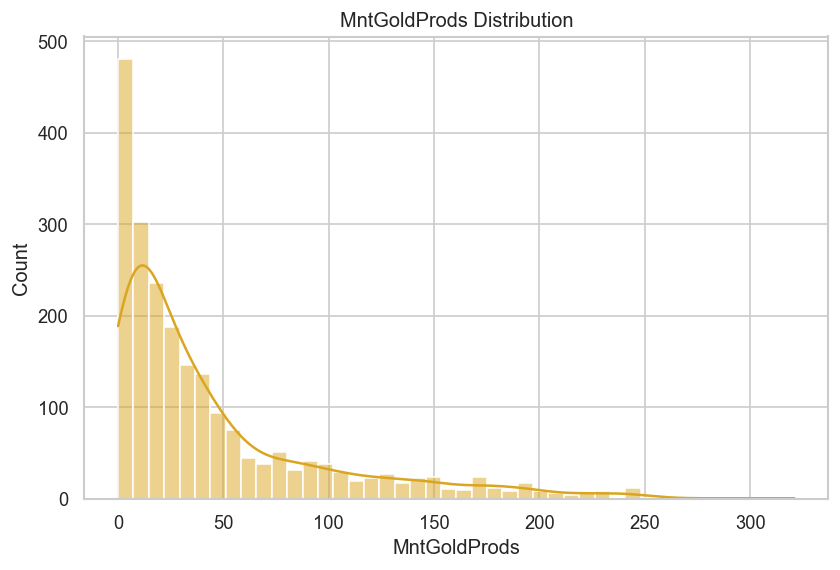

In [100]:
#Check All the Values on MntGoldProds Overview distribution 

# Filter data for visualization only
df_gold = df_prep[df_prep['MntGoldProds'] < 350]

plt.figure(figsize=(8, 5))
sns.histplot(df_gold['MntGoldProds'], kde=True, color='goldenrod')
plt.title('MntGoldProds Distribution')
plt.show()

In [101]:
#Clip outliers in MntGoldProds

df_prep['MntGoldProds'] = df_prep['MntGoldProds'].clip(upper=gold_99)
print(f'Gold Products max after clipping: {df_prep["MntGoldProds"].max():,.0f}')

Gold Products max after clipping: 227


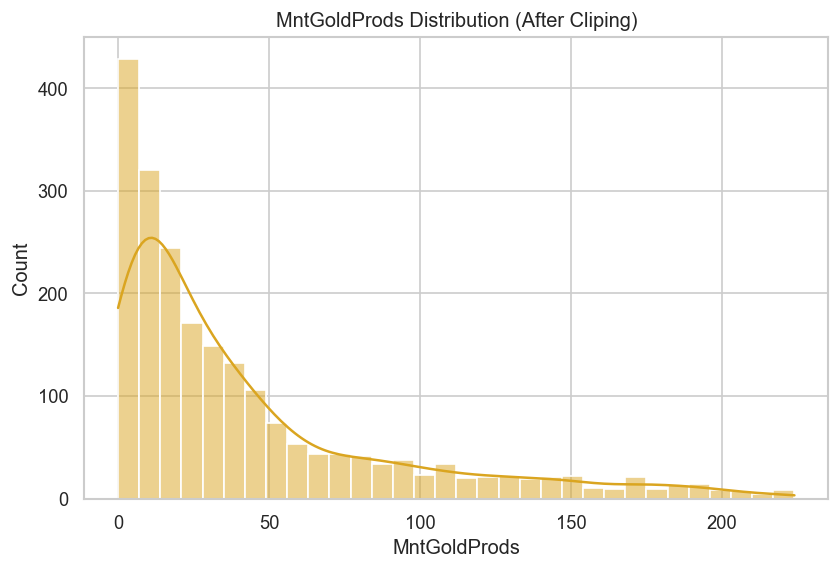

In [102]:
#Check All the Values on MntGoldProd after Cliping

# Filter data for visualization only
df_gold = df_prep[df_prep['MntGoldProds'] < 227]

plt.figure(figsize=(8, 5))
sns.histplot(df_gold['MntGoldProds'], kde=True, color='goldenrod')
plt.title('MntGoldProds Distribution (After Cliping)')
plt.show()

#### MntFishProducts Variable

In [103]:
display(df_prep['MntFishProducts'].describe())

count    2240.000000
mean       37.523661
std        54.630198
min        -1.000000
25%         3.000000
50%        12.000000
75%        50.000000
max       259.000000
Name: MntFishProducts, dtype: float64

In [104]:
#Total amount for each unique values in MntFishProducts
value_counts = df_prep['MntFishProducts'].value_counts()
print("Frequency of each spending amount:")
print(value_counts.head())

Frequency of each spending amount:
MntFishProducts
0    383
2    155
3    130
4    108
6     82
Name: count, dtype: int64


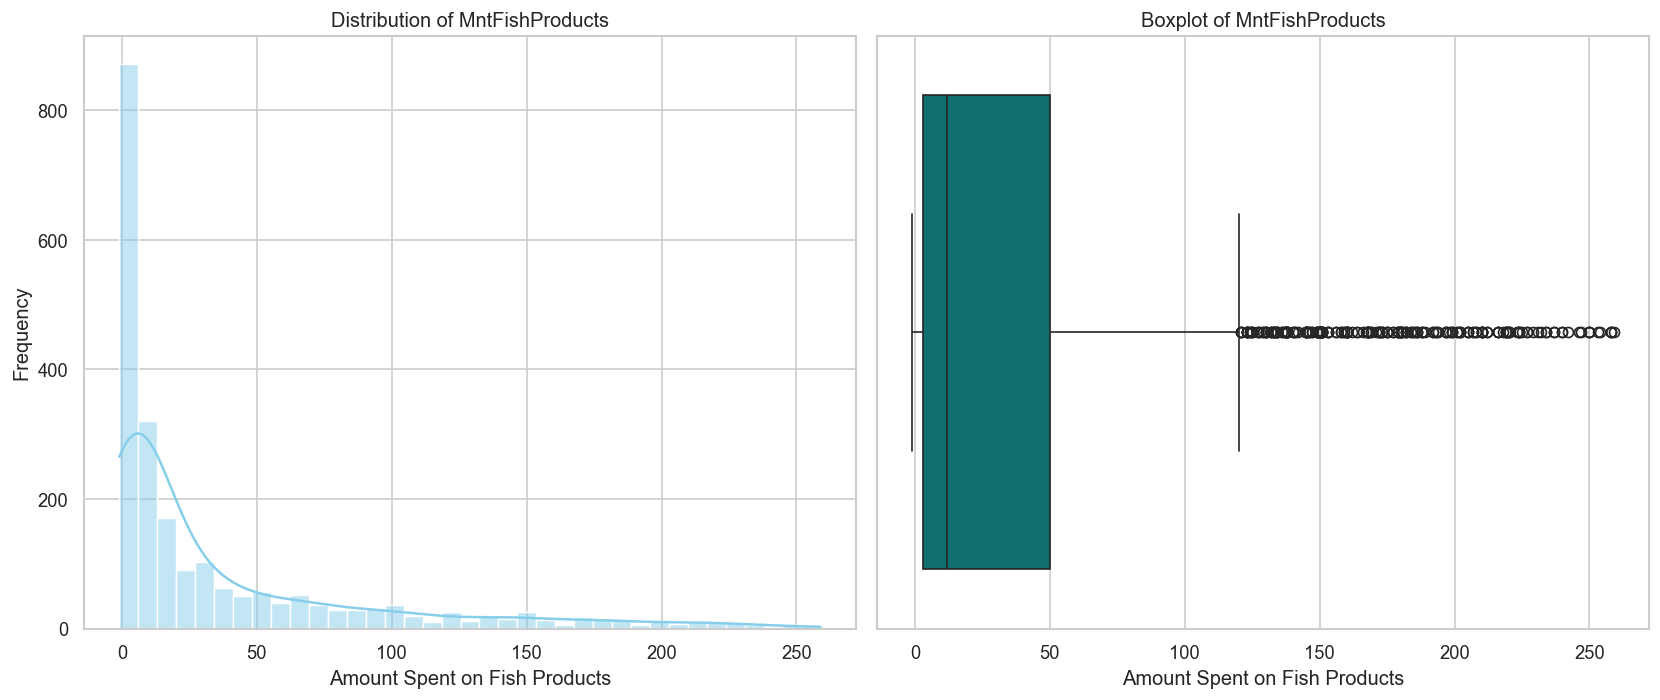

In [105]:
# Visualize MntFishProducts
sns.set_theme(style="whitegrid")

# Create a figure with a Histogram and a Boxplot
plt.figure(figsize=(14, 6))

#Histogram 
plt.subplot(1, 2, 1)
sns.histplot(df_prep['MntFishProducts'], kde=True, color='skyblue')
plt.title('Distribution of MntFishProducts')
plt.xlabel('Amount Spent on Fish Products')
plt.ylabel('Frequency')

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_prep['MntFishProducts'], color='teal')
plt.title('Boxplot of MntFishProducts')
plt.xlabel('Amount Spent on Fish Products')

plt.tight_layout()
plt.show()

In [106]:
#Fix Invalid Fish Spending
df_prep.loc[df_prep['MntFishProducts'] < 0, 'MntFishProducts'] = 0

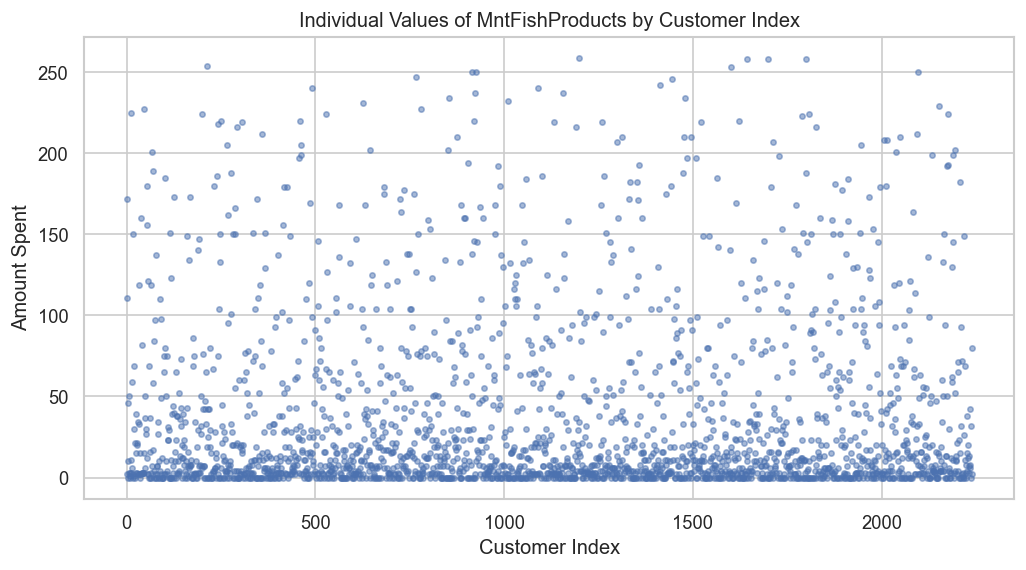

In [107]:
#Check All MntFishProducts Values

plt.figure(figsize=(10, 5))
plt.scatter(df_prep.index, df_prep['MntFishProducts'], alpha=0.5, s=10)
plt.title('Individual Values of MntFishProducts by Customer Index')
plt.xlabel('Customer Index')
plt.ylabel('Amount Spent')
plt.show()

#### Income

In [108]:
display(df_prep['Income'].describe())

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

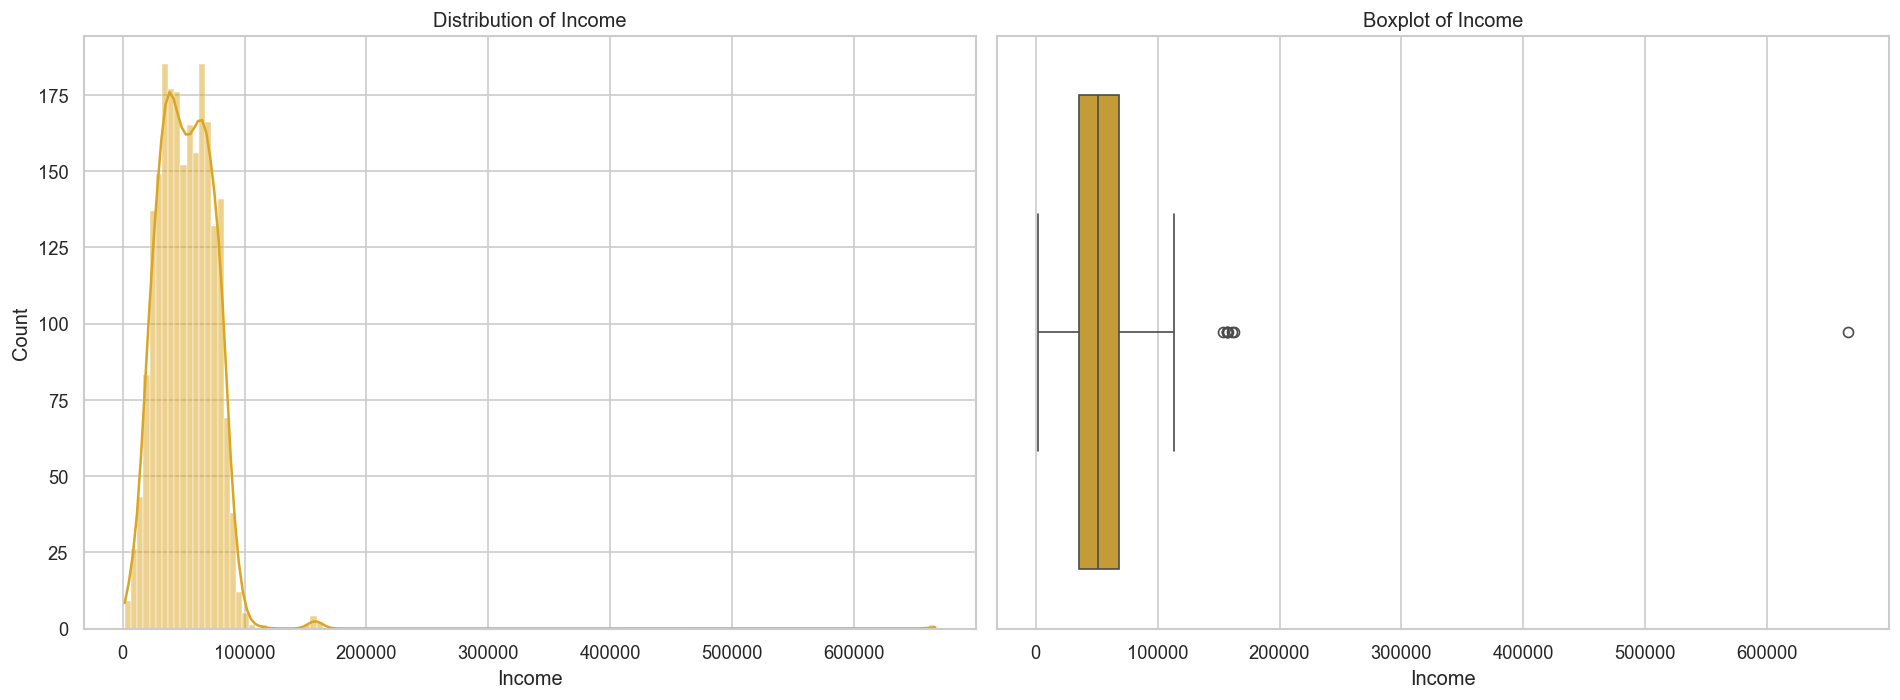

In [109]:
#View Income status

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

#Histogram 
plt.subplot(1, 2, 1)
sns.histplot(df_prep['Income'].dropna(), kde=True, color='goldenrod')
plt.title('Distribution of Income')
plt.xlabel('Income')

# Boxplot 
plt.subplot(1, 2, 2)
sns.boxplot(x=df_prep['Income'], color='goldenrod')
plt.title('Boxplot of Income')
plt.xlabel('Income')

plt.tight_layout()
plt.show()

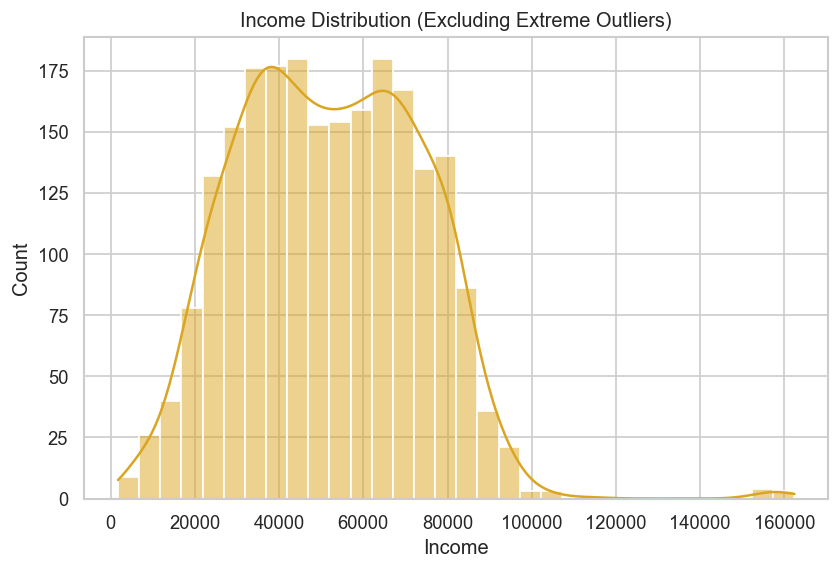

In [110]:
# Filter data for visualization only
df_income = df_prep[df_prep['Income'] < 200000]

plt.figure(figsize=(8, 5))
sns.histplot(df_income['Income'], kde=True, color='goldenrod')
plt.title('Income Distribution (Excluding Extreme Outliers)')
plt.show()

In [111]:
#Check Income Outliers 

income_99 = df_prep['Income'].quantile(0.99)
print(f'Income 99th percentile: {income_99:,.0f}')

Income 99th percentile: 94,459


In [112]:
#Clip outliers in income

df_prep['Income'] = df_prep['Income'].clip(upper=income_99)
print(f'Income max after clipping: {df_prep["Income"].max():,.0f}')

Income max after clipping: 94,459


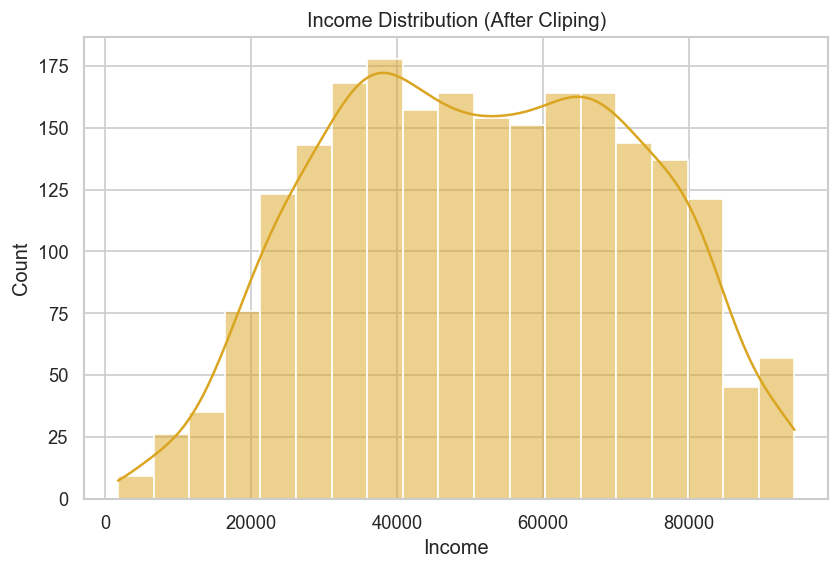

In [113]:
#Check Income after cliping 

df_income = df_prep[df_prep['Income'] < 200000]

plt.figure(figsize=(8, 5))
sns.histplot(df_income['Income'], kde=True, color='goldenrod')
plt.title('Income Distribution (After Cliping)')
plt.show()

In [114]:
#Check Missing values in income

print(df_prep['Income'].isnull().sum()[df_prep['Income'].isnull().sum() > 0])

[24]


In [115]:
# Calculate the median income for each education level

df_prep['Income'] = df_prep['Income'].fillna(df_prep.groupby('Education')['Income'].transform('median'))

In [116]:
#Check Missing values in income after imputation 

print(df_prep['Income'].isnull().sum()[df_prep['Income'].isnull().sum() > 0])

[]


#### Education Variable 

In [117]:
display(df_prep['Education'].describe())

count           2240
unique             5
top       Graduation
freq            1127
Name: Education, dtype: object

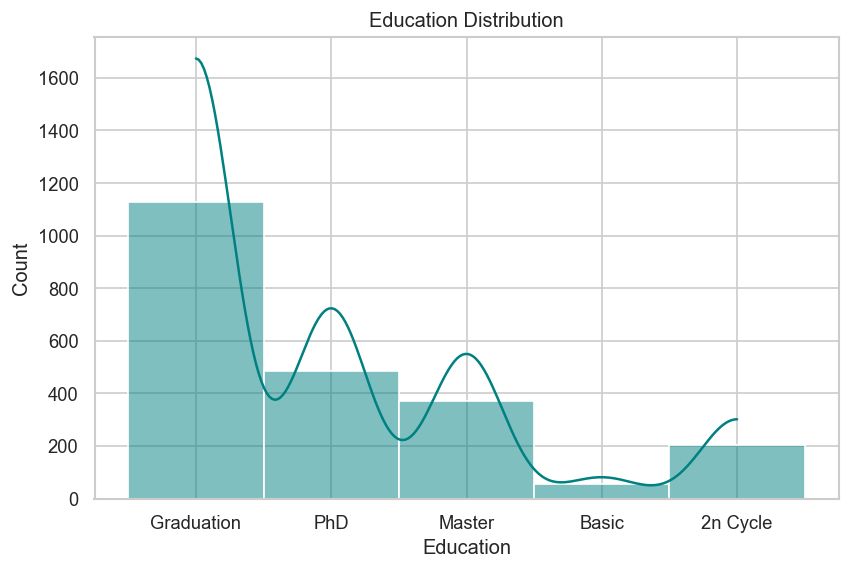

In [118]:
#Check Education

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Education'], kde=True, color='teal')
plt.title('Education Distribution')
plt.show()

#### Year_Birth

In [119]:
display(df_prep['Year_Birth'].describe())

count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64

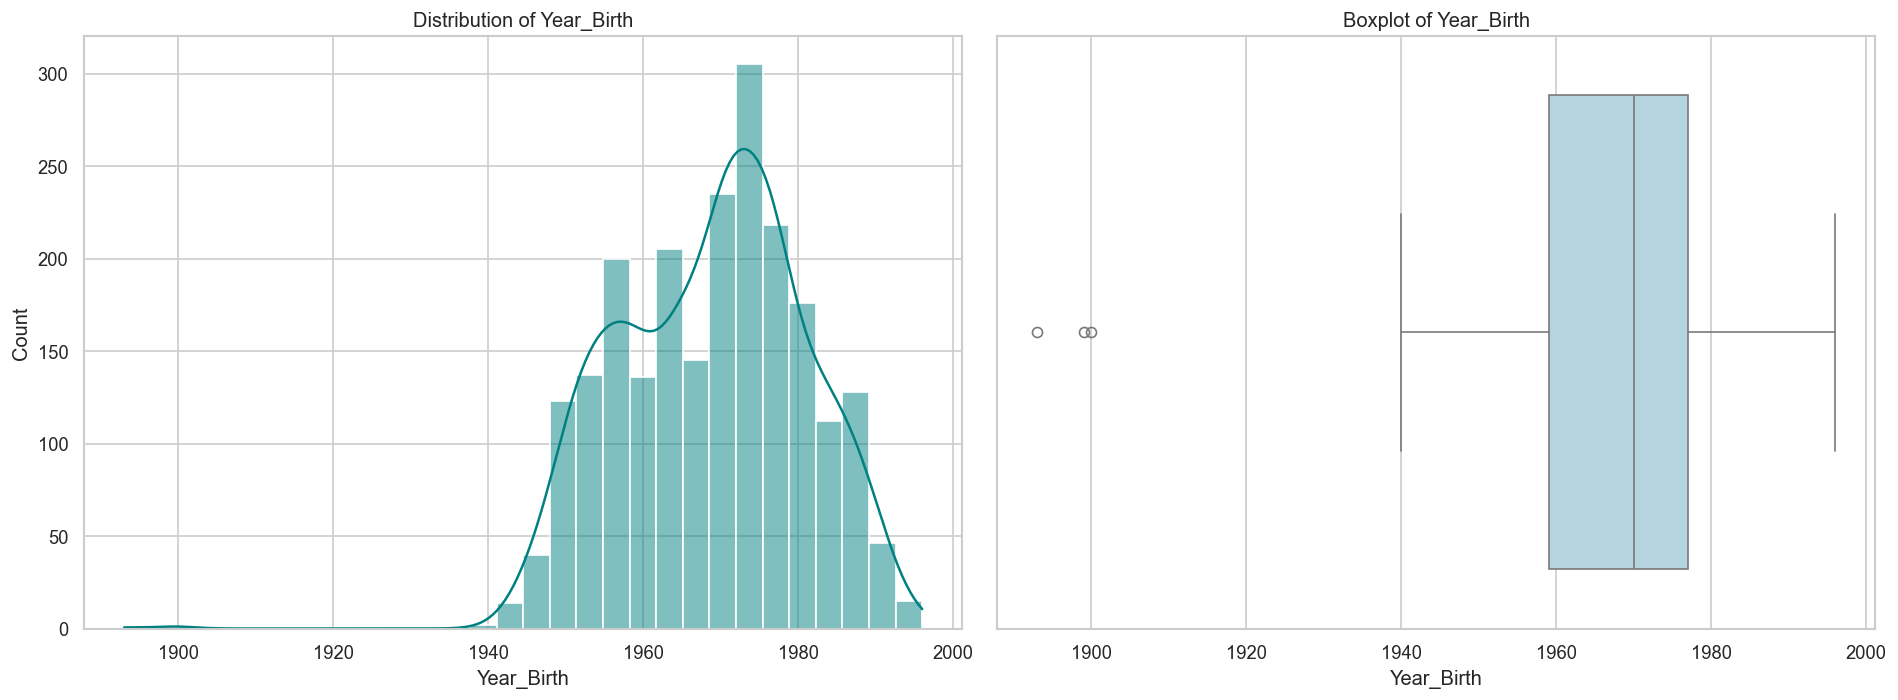

In [120]:
#Check Year of birth 

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Year_Birth'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Year_Birth')

#Boxplot
sns.boxplot(x=df_prep['Year_Birth'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Year_Birth')

plt.tight_layout()
plt.show()


In [121]:
#Check last enrollment in the database
#Convert to datetime format first
df_prep['Dt_Customer'] = pd.to_datetime(df_prep['Dt_Customer'])

#Find the most "recent" enrollment date in the DB
last_enrollment = df_prep['Dt_Customer'].max()
print(f"The last customer enrolled on: {last_enrollment}")

#Find the ID of that customer
last_cust = df_prep[df_prep['Dt_Customer'] == last_enrollment]['ID'].values
print(f"Customer ID(s) for this enrollment: {last_cust}")


The last customer enrolled on: 2042-11-09 00:00:00
Customer ID(s) for this enrollment: [9909]


Observations: 
Some kind of error in the dataset, since the last customer enter in the future (2042). Probably a miss spelling error or some kind of typo. 

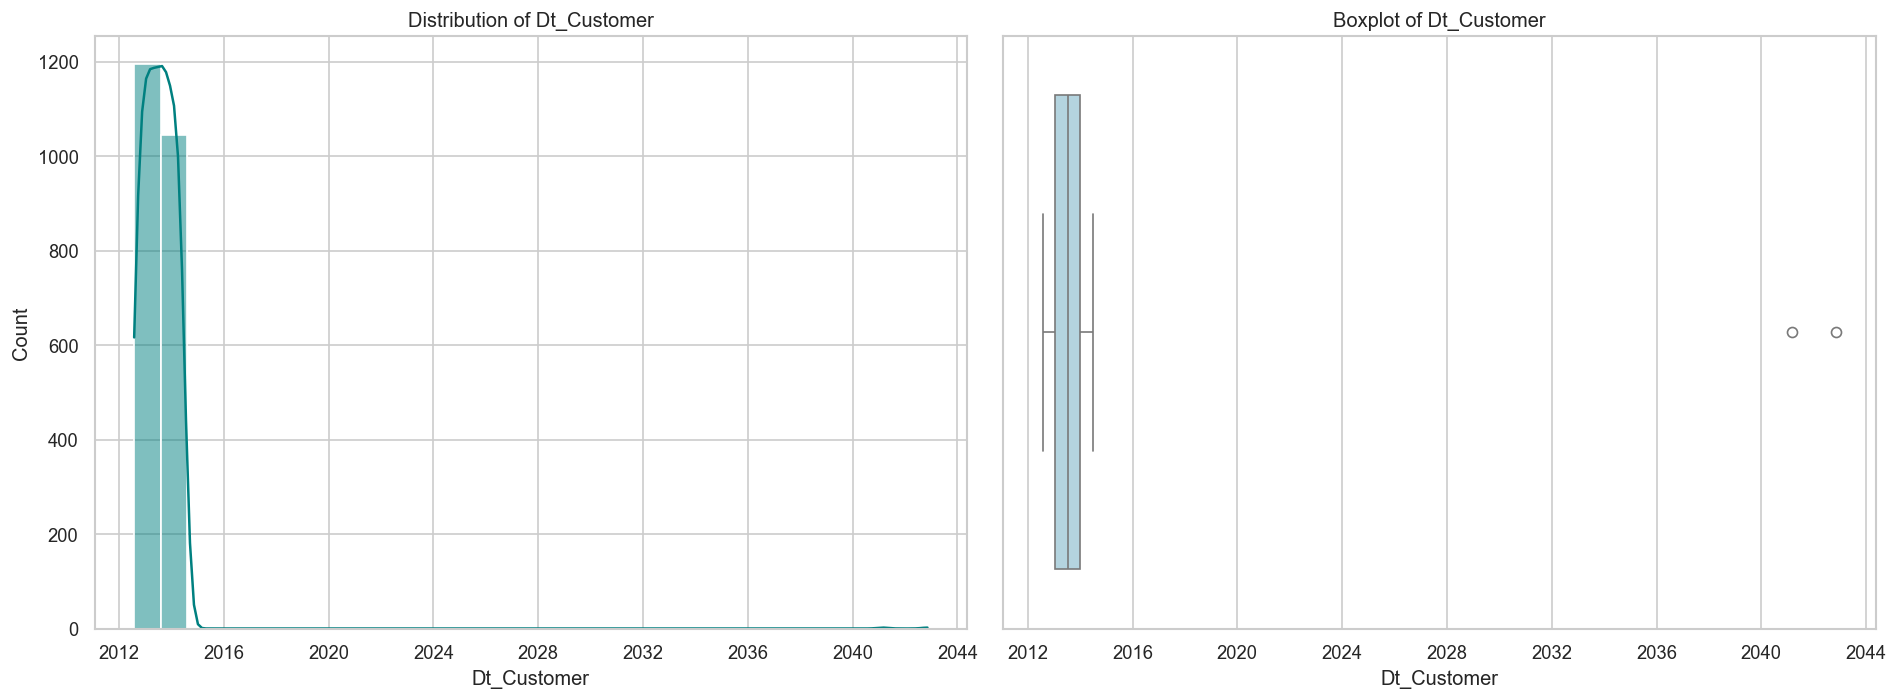

In [122]:
#Check last enrollment in the database

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Dt_Customer'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Dt_Customer')

#Boxplot
sns.boxplot(x=df_prep['Dt_Customer'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Dt_Customer')

plt.tight_layout()
plt.show()


In [123]:
display(df_prep['Dt_Customer'].describe())

count                             2240
mean     2013-07-19 17:05:21.428571392
min                2012-07-30 00:00:00
25%                2013-01-16 18:00:00
50%                2013-07-09 00:00:00
75%                2013-12-31 00:00:00
max                2042-11-09 00:00:00
Name: Dt_Customer, dtype: object

In [124]:
#Check Dt_Customer Outliers 

customer_99 = df_prep['Dt_Customer'].quantile(0.99)
print(f"Dt_Customer 99th percentile: {customer_99}")

Dt_Customer 99th percentile: 2014-06-22 14:38:24


In [125]:
#Check maximum value 
print(f"Latest enrollment in dataset: {df_prep['Dt_Customer'].max()}")

Latest enrollment in dataset: 2042-11-09 00:00:00


In [126]:
#Identify the specific rows that are over 2026

outliers = df_prep[df_prep['Dt_Customer'] > '2016-01-01']
print("\nRows with future enrollment dates:")
print(outliers[['ID', 'Dt_Customer']])


Rows with future enrollment dates:
      ID Dt_Customer
46  9909  2042-11-09
84   535  2041-02-25


In [127]:
#Identify the last realistic date 

last_realistic_date = df_prep[df_prep['Dt_Customer'] < '2016-01-01']['Dt_Customer'].max()
print(f"The last realistic enrollment date is: {last_realistic_date}")

The last realistic enrollment date is: 2014-06-29 00:00:00


In [128]:
#Caping the future values 
df_prep.loc[df_prep['Dt_Customer'] > last_realistic_date, 'Dt_Customer'] = last_realistic_date

In [129]:
#Check fix
print(f"New maximum date in dataset: {df_prep['Dt_Customer'].max()}")

New maximum date in dataset: 2014-06-29 00:00:00


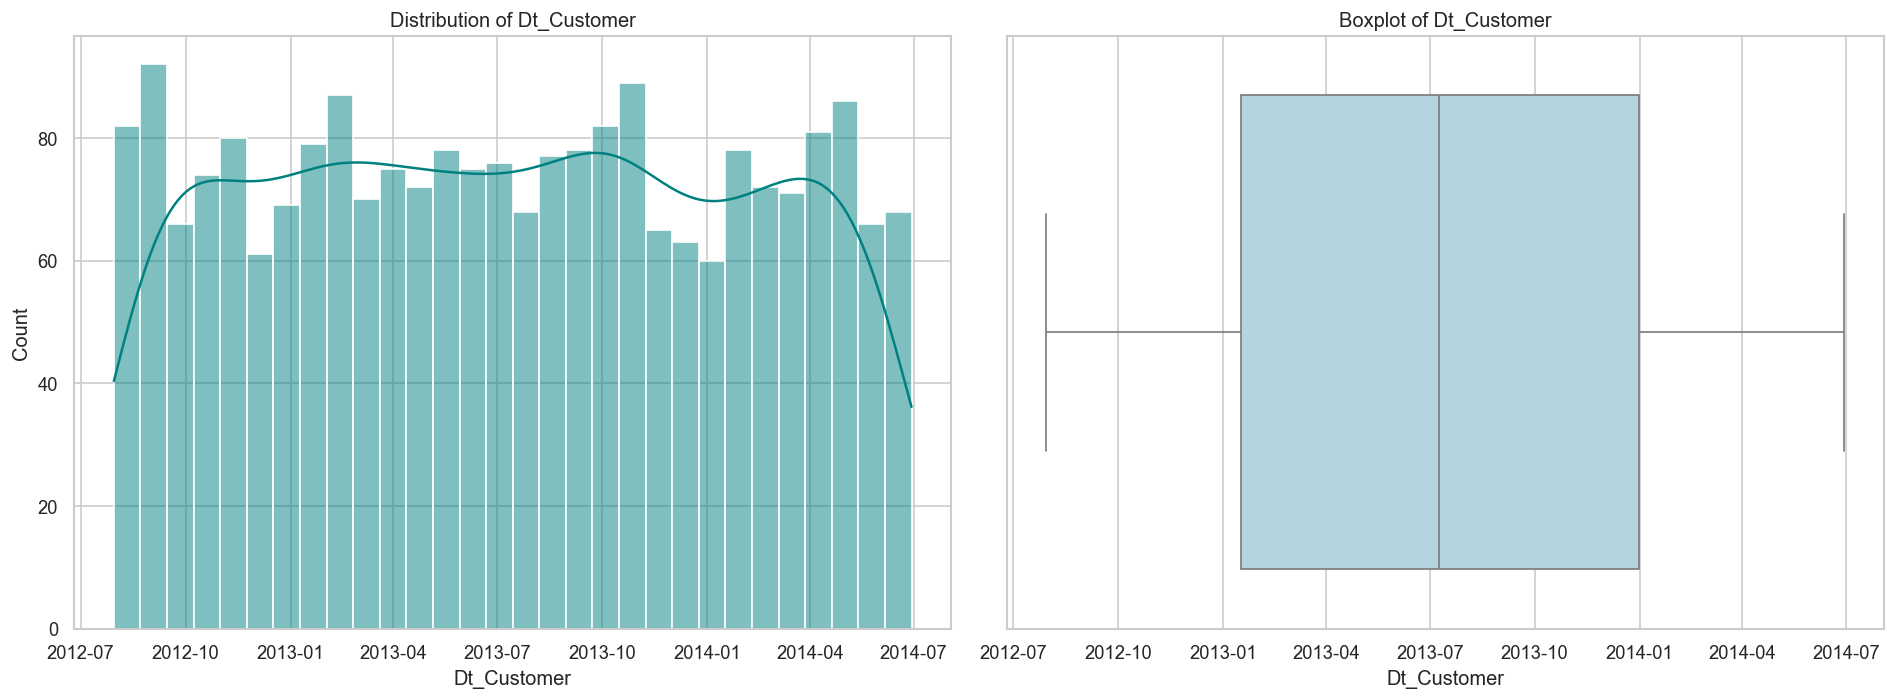

In [130]:
#Check last enrollment in the database after prep

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Dt_Customer'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Dt_Customer')

#Boxplot
sns.boxplot(x=df_prep['Dt_Customer'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Dt_Customer')

plt.tight_layout()
plt.show()


In [131]:
#Now, Convert Date to "Days as Customer"
reference_date = df_prep['Dt_Customer'].max() 
df_prep['Seniority'] = (reference_date - df_prep['Dt_Customer']).dt.days

In [132]:
# NOW you can use your numeric percentile code
seniority_99 = df_prep['Seniority'].quantile(0.99)
print(f'Seniority 99th percentile: {seniority_99:,.0f} days')

Seniority 99th percentile: 691 days


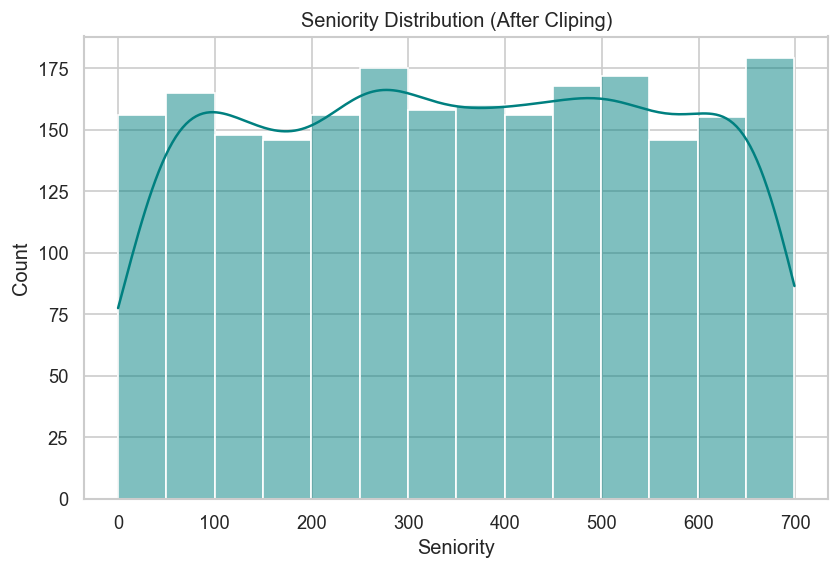

In [133]:
#Check Seniority 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Seniority'], kde=True, color='teal')
plt.title('Seniority Distribution (After Cliping)')
plt.show()

In [134]:
display(df_prep['Seniority'].describe())

count    2240.000000
mean      353.260268
std       202.274756
min         0.000000
25%       180.000000
50%       355.000000
75%       528.250000
max       699.000000
Name: Seniority, dtype: float64

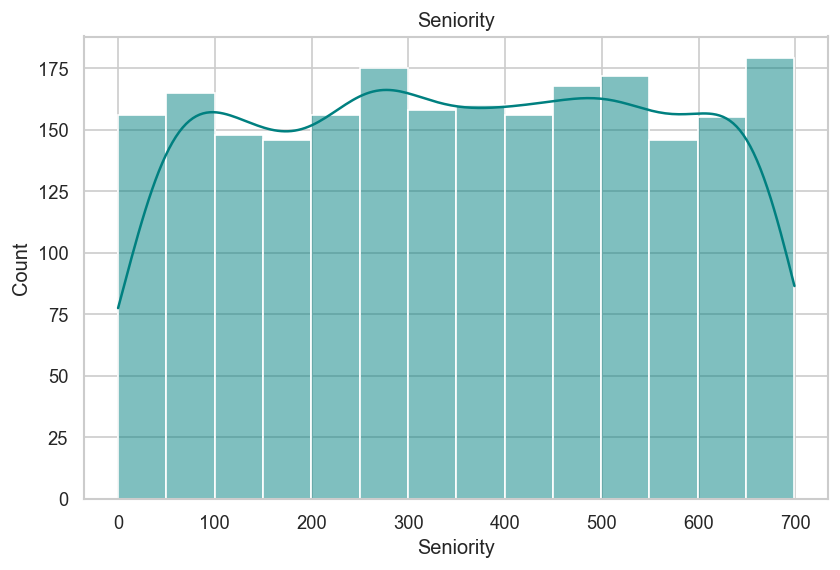

In [135]:
#Check Seniority after change 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Seniority'], kde=True, color='teal')
plt.title('Seniority')
plt.show()

Observations: 
+ After checking and changing the last customer in the dataset (2014-06-29), this date passed to be a seniority in days. 
+ Next, the Age of the customers will be updated according to the last year in the database and not the actual year we are in. 

In [136]:
#Create Age variable
df_prep['Age'] = 2014 - df_prep['Year_Birth']

In [137]:
#Drop the original Year_Birth column and replace by age 
df_prep.drop(columns=['Year_Birth'], inplace=True)

#Check the results
print(df_prep['Age'].describe())

count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: Age, dtype: float64


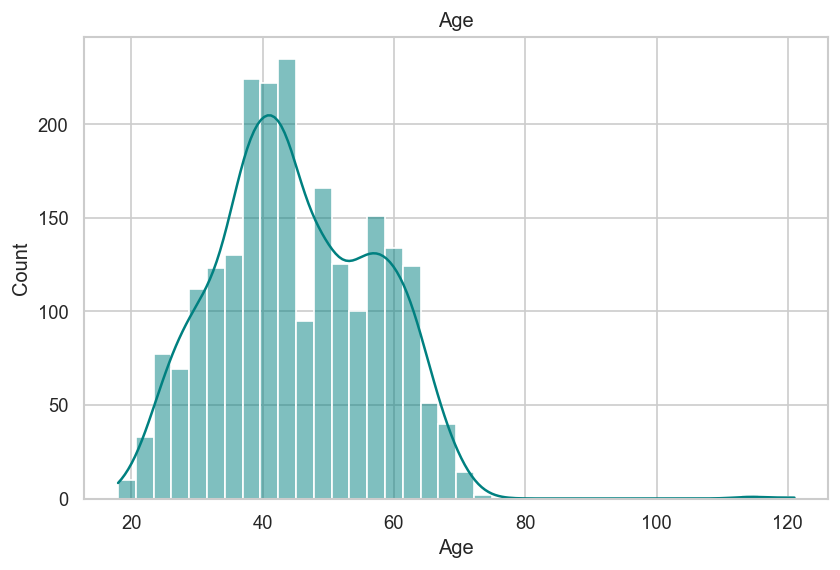

In [138]:
#Check Age 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Age'], kde=True, color='teal')
plt.title('Age')
plt.show()

#### Marital_Status

In [139]:
#Check Marital Status Values 
print('Marital_Status value counts:')
print(df_prep['Marital_Status'].value_counts())

Marital_Status value counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


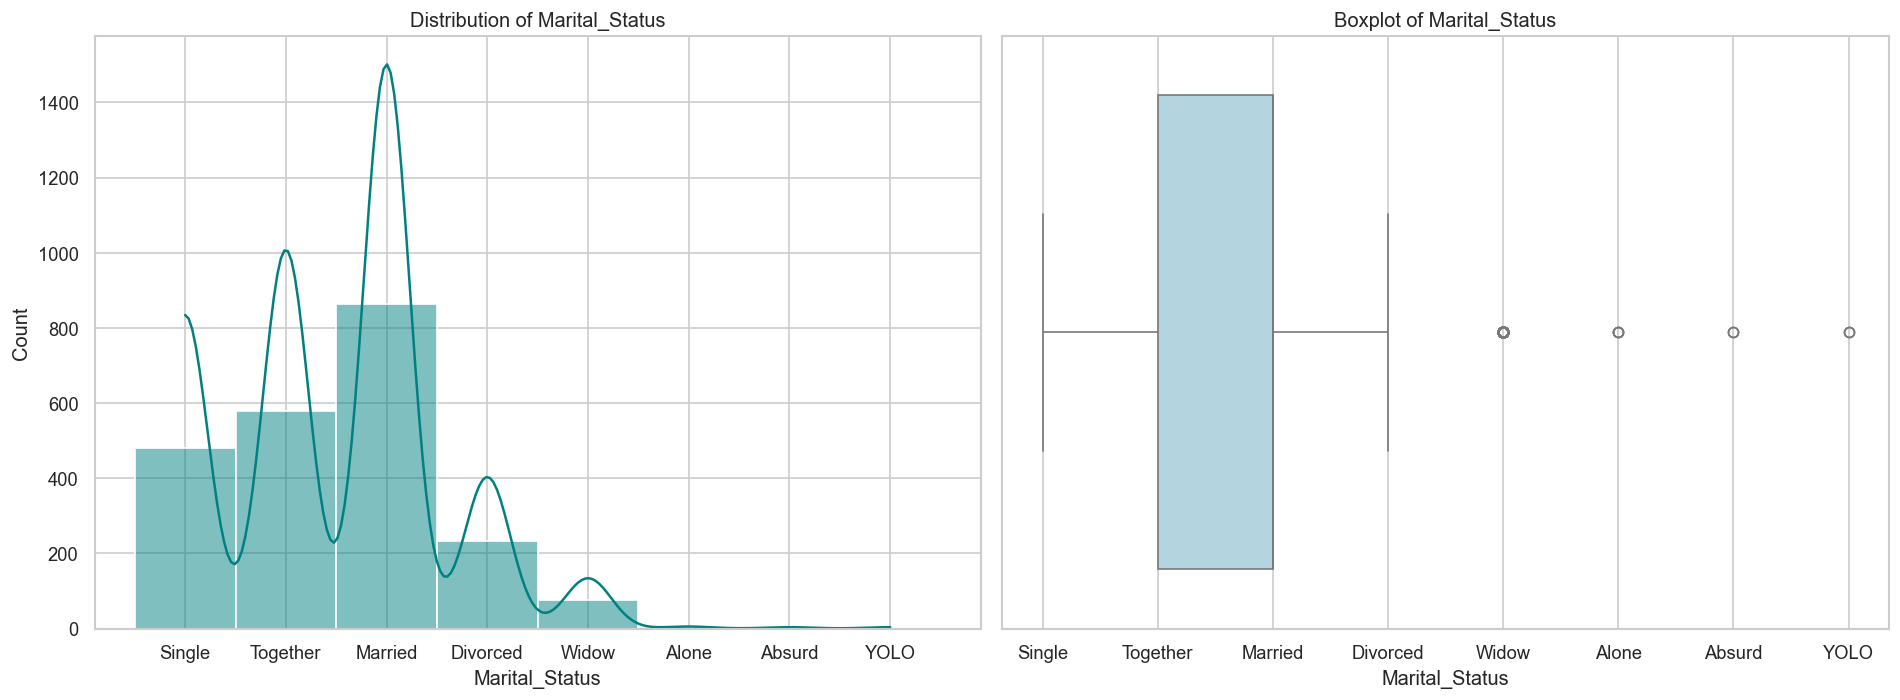

In [140]:
#Check Marital Status

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Marital_Status'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Marital_Status')

#Boxplot
sns.boxplot(x=df_prep['Marital_Status'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Marital_Status')

plt.tight_layout()
plt.show()


In [141]:
#Replace alone categories in Marital_Status to single 
df_prep['Marital_Status'] = df_prep['Marital_Status'].replace(['Absurd', 'YOLO', 'Alone'], 'Single')

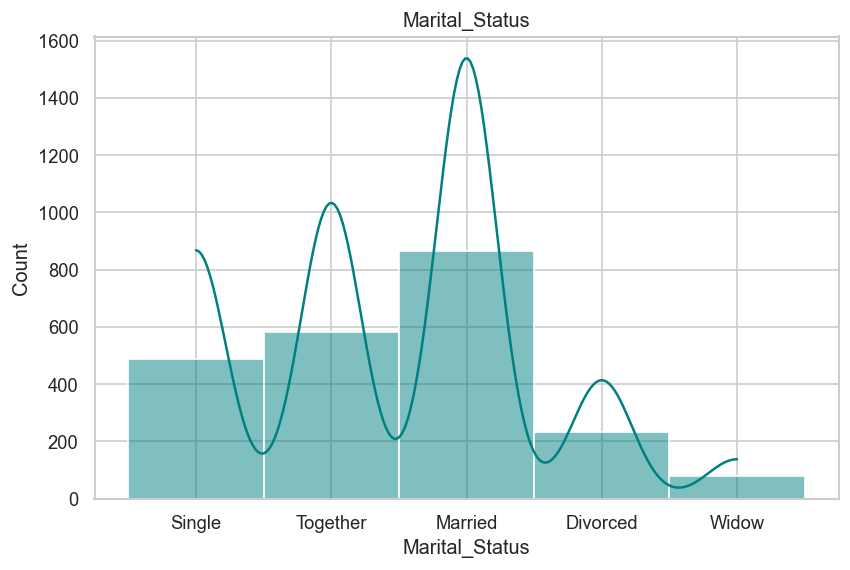

In [142]:
#Check Marital_Status after change 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Marital_Status'], kde=True, color='teal')
plt.title('Marital_Status')
plt.show()

#### MntGoldProds Variable 

In [143]:
display(df_prep['MntGoldProds'].describe())

count    2187.000000
mean       44.341180
std        51.362621
min         0.000000
25%         9.000000
50%        25.000000
75%        57.000000
max       227.280000
Name: MntGoldProds, dtype: float64

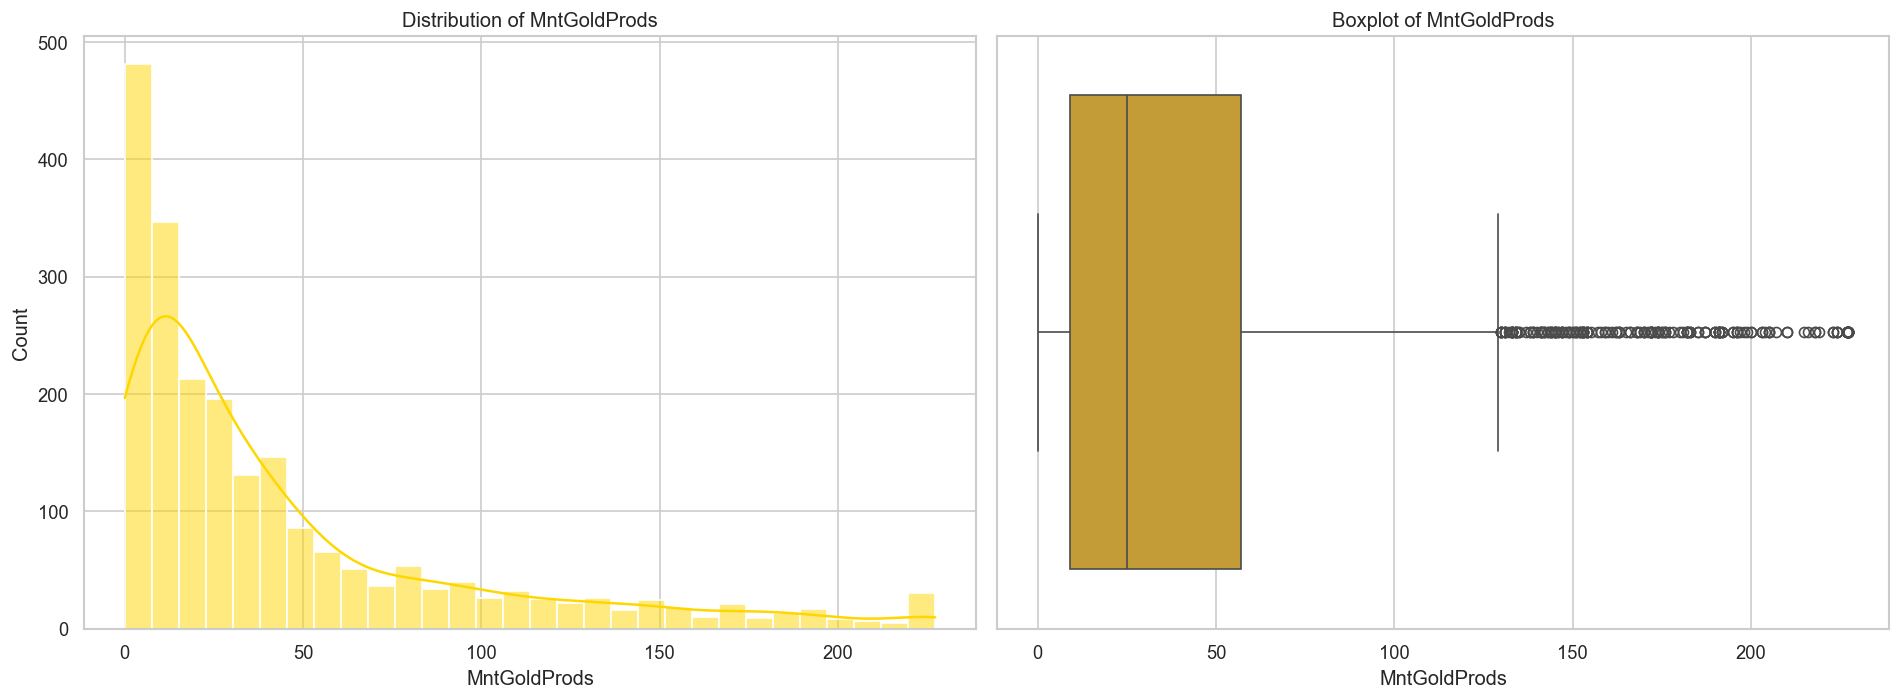

In [144]:
#Check MntGoldProds

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['MntGoldProds'], bins=30, kde=True, ax=axes[0], color='gold')
axes[0].set_title('Distribution of MntGoldProds')

#Boxplot
sns.boxplot(x=df_prep['MntGoldProds'], ax=axes[1], color='goldenrod')
axes[1].set_title('Boxplot of MntGoldProds')

plt.tight_layout()
plt.show()


In [145]:
#Calculate IQR
Q1 = df_prep['MntGoldProds'].quantile(0.25)
Q3 = df_prep['MntGoldProds'].quantile(0.75)
IQR = Q3 - Q1

#Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Identify and count outliers
outliers = df_prep[(df_prep['MntGoldProds'] < lower_bound) | (df_prep['MntGoldProds'] > upper_bound)]
print(f"Number of outliers in MntGoldProds: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df_prep)*100:.2f}%")

Number of outliers in MntGoldProds: 200
Percentage of outliers: 8.93%


In [146]:
#Calculate 95th percentile
cap_value = df_prep['MntGoldProds'].quantile(0.95)

#Apply the cap above the 95th percentile
df_prep['MntGoldProds'] = df_prep['MntGoldProds'].clip(upper=cap_value)

print(f"Values in MntGoldProds capped at: {cap_value}")

Values in MntGoldProds capped at: 166.0


In [147]:
#Check Missing values in MntGoldProds 

print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

MntGoldProds    53
dtype: int64


In [148]:
#Numeric features to predict gold spending (Income, MntWines, and other spending categories) using KNN

impute_cols = ['Income', 'MntWines', 'MntMeatProducts', 'MntFishProducts', 'MntGoldProds']

In [149]:
from sklearn.impute import KNNImputer

#Initiate the KNN Imputer (K=5 is standard)
knn_imputer = KNNImputer(n_neighbors=5)

#Do imputation
df_prep[impute_cols] = knn_imputer.fit_transform(df_prep[impute_cols])

print("Missing values in MntGoldProds after KNN:", df_prep['MntGoldProds'].isnull().sum())

Missing values in MntGoldProds after KNN: 0


In [150]:
#Check Missing values in MntGoldProds after KNN

print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

Series([], dtype: int64)


In [151]:
display(df_prep['MntGoldProds'].describe())

count    2240.000000
mean       42.350625
std        46.235386
min         0.000000
25%         9.000000
50%        25.000000
75%        56.000000
max       166.000000
Name: MntGoldProds, dtype: float64

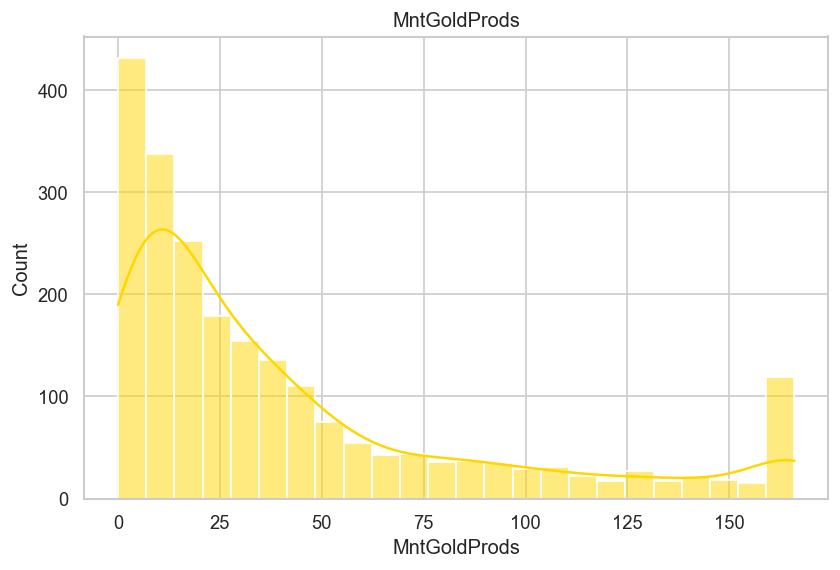

In [152]:
#Check MntGoldProds after change 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['MntGoldProds'], kde=True, color='gold')
plt.title('MntGoldProds')
plt.show()

### Drop Columns

In [153]:
# Check Z columns constancy 
print("Nunique for Z columns:\n", df_prep[['Z_CostContact', 'Z_Revenue']].nunique())

print("\nValue counts for Z_CostContact:")
print(df_prep['Z_CostContact'].value_counts())

print("\nValue counts for Z_Revenue:")
print(df_prep['Z_Revenue'].value_counts())

Nunique for Z columns:
 Z_CostContact    1
Z_Revenue        1
dtype: int64

Value counts for Z_CostContact:
Z_CostContact
3    2240
Name: count, dtype: int64

Value counts for Z_Revenue:
Z_Revenue
11    2240
Name: count, dtype: int64


In [154]:
#Drop Columns 

df_prep.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer'], inplace=True)
print(f'Shape after dropping: {df_prep.shape}')

Shape after dropping: (2240, 26)


### Feature Engineering 

In [155]:
#Sum of all product Spending 

spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_prep['TotalSpent'] = df_prep[spend_cols].sum(axis=1)

In [156]:
#Total Accepted 

accepted_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5']
df_prep['TotalAccepted'] = df_prep[accepted_cols].sum(axis=1)

In [157]:
# Total Children 
df_prep['Total_Children'] = df_prep['Kidhome'] + df_prep['Teenhome']

In [158]:
print(f'Shape after feature engineering: {df_prep.shape}')
df_prep[['Age', 'TotalSpent', 'TotalAccepted', 'Total_Children']].describe()

Shape after feature engineering: (2240, 29)


,Age,TotalSpent,TotalAccepted,Total_Children
count,2240.000000,2.240000e+03,2240.000000,2240.000000
mean,45.194196,1.221088e+04,0.297768,0.950446
std,11.984069,4.973984e+05,0.678381,0.751803
min,18.000000,5.000000e+00,0.000000,0.000000
25%,37.000000,6.900000e+01,0.000000,0.000000
50%,44.000000,3.960000e+02,0.000000,1.000000
75%,55.000000,1.045500e+03,0.000000,1.000000
max,121.000000,2.342483e+07,4.000000,3.000000


### Encode Categorical Variables 

In [159]:
#Check before encode Marital Status 

print('Marital_Status value counts:')
print(df_prep['Marital_Status'].value_counts())

Marital_Status value counts:
Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [160]:
#Check before encode Education

print('Education value counts:')
print(df_prep['Education'].value_counts())

Education value counts:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [161]:
# One-hot encode with k-1 dummies (drop_first=True)
df_prep = pd.get_dummies(df_prep, columns=['Education', 'Marital_Status'], drop_first=True)
print(f'Shape after encoding: {df_prep.shape}')
df_prep.head(2)

Shape after encoding: (2240, 35)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,TotalAccepted,Total_Children,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,58138.0,0,0,58,635.0,88.0,546.0,172.0,88,88.0,...,0,0,False,True,False,False,False,True,False,False
1,46344.0,1,1,38,11.0,1.0,6.0,2.0,1,6.0,...,0,2,False,True,False,False,False,True,False,False


### Check Response Variable (Class balance)

Target distribution:
Response
0    1906
1     334
Name: count, dtype: int64

Class imbalance ratio: 5.7:1 (No:Yes)


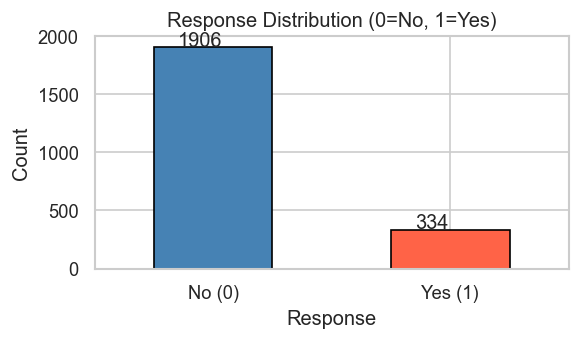

In [162]:
#Class Balance Target variable Response 

print('Target distribution:')
counts = df_prep['Response'].value_counts()
print(counts)
print(f'\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1 (No:Yes)')

fig, ax = plt.subplots(figsize=(5,3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Response Distribution (0=No, 1=Yes)')
ax.set_xlabel('Response')
ax.set_ylabel('Count')
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.1, p.get_height()+10))
plt.tight_layout()
plt.show()

### Train and Test

In [163]:
# Drop the target 
TARGET = 'Response'
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

# Split data (20/80)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')
print(f'Train Response distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'Test Response distribution:\n{y_test.value_counts(normalize=True).round(3)}')

Train size : 1792 rows
Test size  : 448 rows
Train Response distribution:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64
Test Response distribution:
Response
0    0.85
1    0.15
Name: proportion, dtype: float64


## Modeling

In [164]:
#Pipeline scaling 

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   #addresses class imbalance
        max_iter=1000,             #ensure more convergence
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

pipe_lr.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


In [165]:
#Cross validation - Training set 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='accuracy')
cv_prec = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='precision')
cv_rec = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='recall')
cv_f1 = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
cv_auc = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Accuracy:  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Precision: {cv_prec.mean():.4f} ± {cv_prec.std():.4f}")
print(f"Recall:    {cv_rec.mean():.4f} ± {cv_rec.std():.4f}")
print(f"F1 Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"ROC AUC:   {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")


Accuracy:  0.8242 ± 0.0151
Precision: 0.4499 ± 0.0271
Recall:    0.7939 ± 0.0320
F1 Score:  0.5742 ± 0.0295
ROC AUC:   0.8924 ± 0.0177


In [166]:
#Coefficient Interpretation. Odds Ratios >1 or <1 (increase or decrease) likehood to respond

model_step = pipe_lr.named_steps['model']
coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': model_step.coef_[0],
    'Odds_Ratio' : np.exp(model_step.coef_[0])
}).sort_values('Odds_Ratio', ascending=False)

print('Top 10 features increasing response probability:')
print(coef_df.head(10).to_string(index=False))
print('\nTop 10 features decreasing response probability:')
print(coef_df.tail(10).to_string(index=False))

Top 10 features increasing response probability:
            Feature  Coefficient  Odds_Ratio
          Seniority     0.996574    2.708985
      Education_PhD     0.532028    1.702381
    MntMeatProducts     0.468006    1.596808
      TotalAccepted     0.441770    1.555458
       AcceptedCmp3     0.413569    1.512206
NumCatalogPurchases     0.351628    1.421380
  NumDealsPurchases     0.304549    1.356013
       AcceptedCmp5     0.301969    1.352519
            Kidhome     0.251302    1.285698
    NumWebPurchases     0.249666    1.283597

Top 10 features decreasing response probability:
                Feature  Coefficient  Odds_Ratio
        MntFishProducts    -0.076096    0.926728
               Complain    -0.092057    0.912053
         Total_Children    -0.166270    0.846818
        Education_Basic    -0.209490    0.810998
               MntWines    -0.237464    0.788626
               Teenhome    -0.477049    0.620612
Marital_Status_Together    -0.518776    0.595249
 Marital_Statu

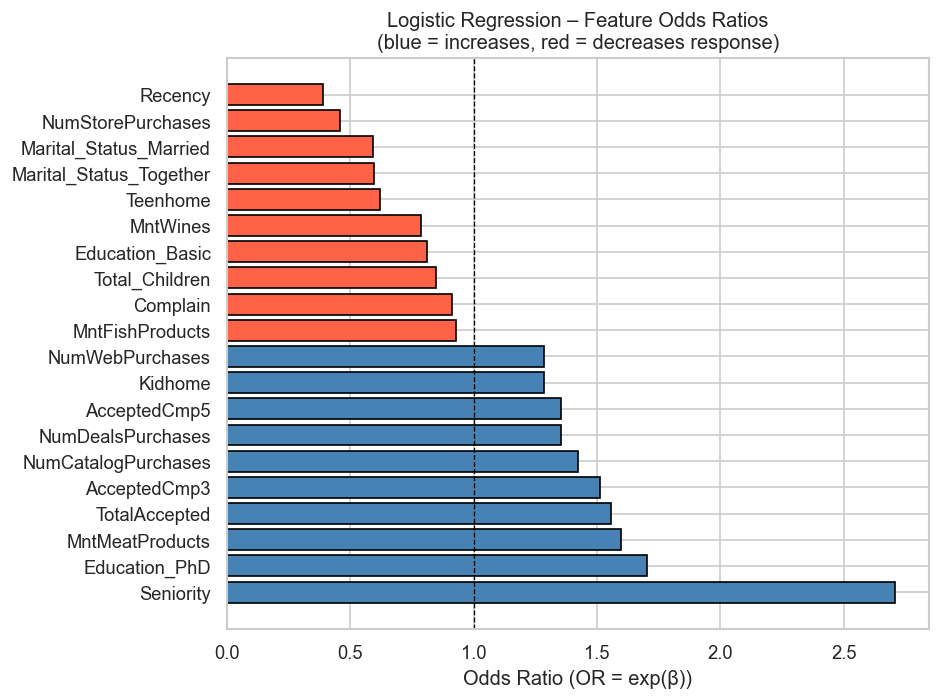

In [167]:
#Check top/bottom 10
top10 = coef_df.head(10)
bot10 = coef_df.tail(10)
plot_df = pd.concat([top10, bot10]).drop_duplicates()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if x < 1 else 'steelblue' for x in plot_df['Odds_Ratio']]
ax.barh(plot_df['Feature'], plot_df['Odds_Ratio'], color=colors, edgecolor='black')
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Odds Ratio (OR = exp(β))')
ax.set_title('Logistic Regression – Feature Odds Ratios\n(blue = increases, red = decreases response)')
plt.tight_layout()
plt.show()

## Evaluation 

In [168]:
#Predictions on test

y_pred       = pipe_lr.predict(X_test)
y_pred_proba = pipe_lr.predict_proba(X_test)[:, 1]  

### Evaluation Metrics
*Recall* is more important than Precision in this business context

In [169]:
#Metrics

print('=' * 50)
print('EVALUATION METRICS – TEST SET')
print('=' * 50)
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Response', 'Response']))

EVALUATION METRICS – TEST SET
Accuracy  : 0.8237
Precision : 0.4483
Recall    : 0.7761
F1-Score  : 0.5683
ROC-AUC   : 0.9028

Classification Report:
              precision    recall  f1-score   support

 No Response       0.95      0.83      0.89       381
    Response       0.45      0.78      0.57        67

    accuracy                           0.82       448
   macro avg       0.70      0.80      0.73       448
weighted avg       0.88      0.82      0.84       448



### Confusion Matrix

- **False Negative (FN):** Misses customer who would have responded - lost revenue($$$$).
- **False Positive (FP):** Contact customers who may not respond - wasted campaign cost ($).

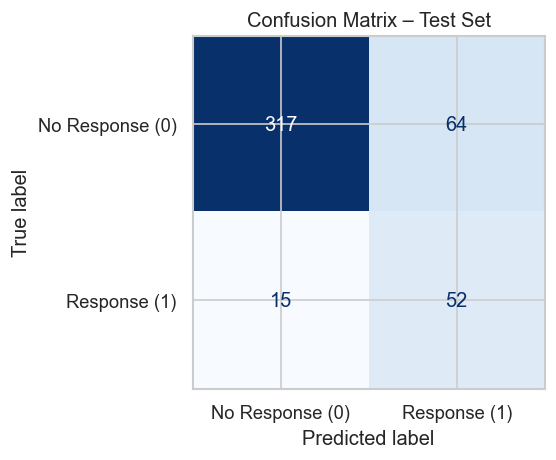

TP=52  FP=64  FN=15  TN=317


In [170]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Response (0)', 'Response (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')

### ROC Curve and AUC

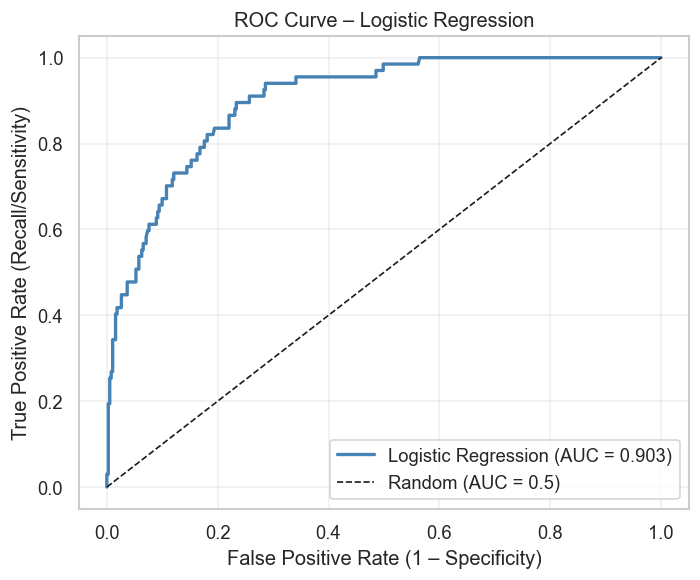

In [171]:
#ROC Curve and AUC 

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 – Specificity)')
ax.set_ylabel('True Positive Rate (Recall/Sensitivity)')
ax.set_title('ROC Curve – Logistic Regression')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Rank Order 

In [172]:
#Rank-order 

rank_df = pd.DataFrame({'y_true': y_test.values, 'y_score': y_pred_proba})
rank_df = rank_df.sort_values('y_score', ascending=False).reset_index(drop=True)

n_total   = len(rank_df)
n_positive = rank_df['y_true'].sum()
n_deciles  = 10
decile_size = n_total // n_deciles

rows = []
for i in range(n_deciles):
    start = i * decile_size
    end   = (i + 1) * decile_size if i < n_deciles - 1 else n_total
    seg   = rank_df.iloc[start:end]
    pos_in_seg = seg['y_true'].sum()
    seg_size   = len(seg)
    gain       = pos_in_seg / n_positive
    lift       = gain / (seg_size / n_total)
    rows.append({'Decile': i+1, 'Size': seg_size,
                 'Positives': int(pos_in_seg),
                 'Gain': round(gain, 4),
                 'Lift': round(lift, 4)})

lift_df = pd.DataFrame(rows)
lift_df['Cum_Gain'] = lift_df['Positives'].cumsum() / n_positive
lift_df['Cum_Lift'] = lift_df['Cum_Gain'] / ((lift_df['Decile'] * decile_size) / n_total)
print(lift_df.to_string(index=False))

 Decile  Size  Positives   Gain   Lift  Cum_Gain  Cum_Lift
      1    44         30 0.4478 4.5590  0.447761  4.559023
      2    44         17 0.2537 2.5834  0.701493  3.571235
      3    44          9 0.1343 1.3677  0.835821  2.836725
      4    44          7 0.1045 1.0638  0.940299  2.393487
      5    44          1 0.0149 0.1520  0.955224  1.945183
      6    44          2 0.0299 0.3039  0.985075  1.671642
      7    44          1 0.0149 0.1520  1.000000  1.454545
      8    44          0 0.0000 0.0000  1.000000  1.272727
      9    44          0 0.0000 0.0000  1.000000  1.131313
     10    52          0 0.0000 0.0000  1.000000  1.018182


### Gains and Lift 


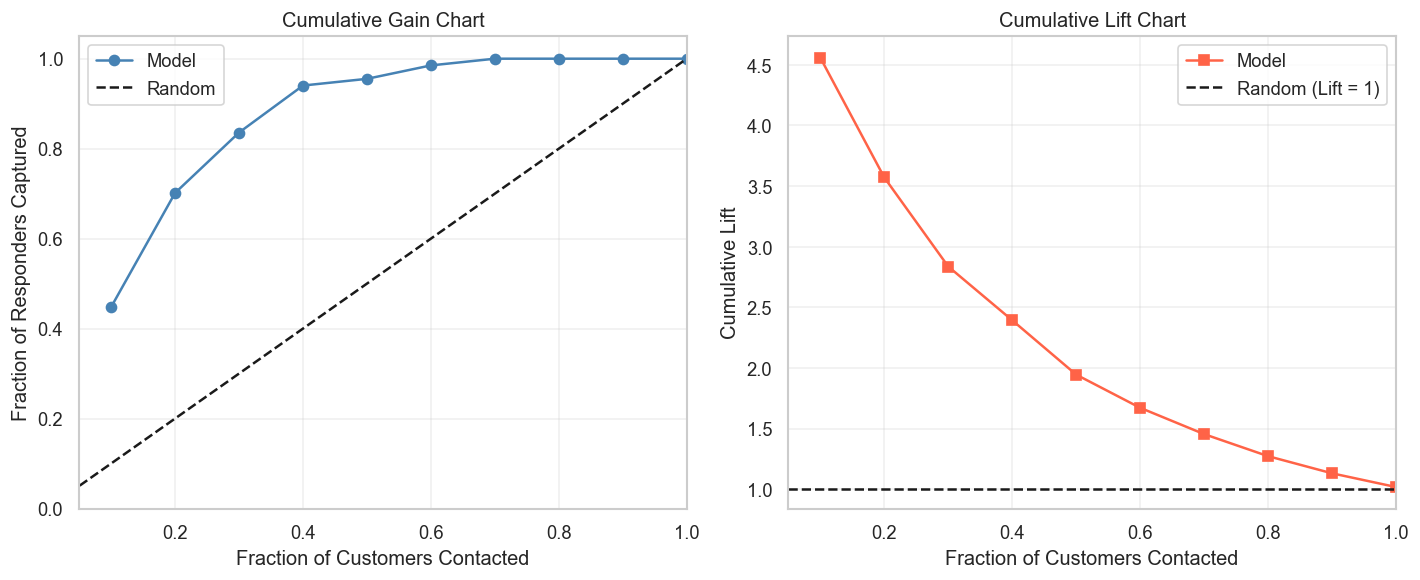

In [173]:
#Comparative Gain and lift chart 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cumulative Gain
ax = axes[0]
ax.plot(lift_df['Decile'] / 10, lift_df['Cum_Gain'], 'o-', color='steelblue', label='Model')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('Fraction of Customers Contacted')
ax.set_ylabel('Fraction of Responders Captured')
ax.set_title('Cumulative Gain Chart')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim([0.05, 1.0])
ax.set_ylim([0, 1.05])

# Cumulative Lift
ax = axes[1]
ax.plot(lift_df['Decile'] / 10, lift_df['Cum_Lift'], 's-', color='tomato', label='Model')
ax.axhline(1.0, color='k', linestyle='--', label='Random (Lift = 1)')
ax.set_xlabel('Fraction of Customers Contacted')
ax.set_ylabel('Cumulative Lift')
ax.set_title('Cumulative Lift Chart')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim([0.05, 1.0])

plt.tight_layout()
plt.show()

### ROI Analysis 

In [174]:
# Adjust these values with the real business figures
TP_PROFIT = 100
FP_COST   = -10
FN_COST   = -100
TN_PROFIT = 0

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

model_roi = tp * TP_PROFIT + fp * FP_COST + fn * FN_COST + tn * TN_PROFIT

# Contact everyone baseline
n_total_test  = len(y_test)
n_pos_test    = y_test.sum()
n_neg_test    = n_total_test - n_pos_test
baseline_roi  = n_pos_test * TP_PROFIT + n_neg_test * FP_COST

print('ROI Analysis (Test Set):')
print(f'  Baseline (contact everyone) : €{baseline_roi:,.0f}')
print(f'  Model (threshold = 0.5)     : €{model_roi:,.0f}')
print(f'  Improvement                 : €{model_roi - baseline_roi:,.0f}')

ROI Analysis (Test Set):
  Baseline (contact everyone) : €2,890
  Model (threshold = 0.5)     : €3,060
  Improvement                 : €170


| Outcome | Description | Revenue/lost| 
|---------|-------------|-------------|
| TP | Customer would respond, contact |  campaign revenue |
| FP | Customer wouldn't respond, contact | campaign cost | 
| FN | Customer would respond, miss contact| lost revenue | 
| TN | Customer wouldn't respond, don't contact | no cost | 

### Evaluation Summary

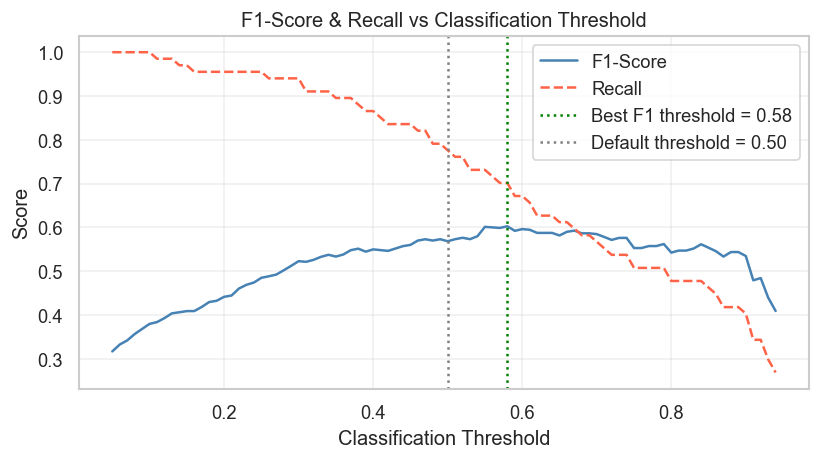

Optimal threshold (max F1): 0.58
F1 at optimal threshold   : 0.6026
Recall at optimal threshold: 0.7015


In [175]:
#Find optimal threshold by F1-score
thresholds_range = np.arange(0.05, 0.95, 0.01)
f1_scores = []
recall_scores = []

for t in thresholds_range:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_t, zero_division=0))

best_f1_idx = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds_range[best_f1_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds_range, f1_scores, label='F1-Score', color='steelblue')
ax.plot(thresholds_range, recall_scores, label='Recall', color='tomato', linestyle='--')
ax.axvline(optimal_threshold_f1, color='green', linestyle=':', label=f'Best F1 threshold = {optimal_threshold_f1:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Default threshold = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('F1-Score & Recall vs Classification Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal threshold (max F1): {optimal_threshold_f1:.2f}')
print(f'F1 at optimal threshold   : {f1_scores[best_f1_idx]:.4f}')
print(f'Recall at optimal threshold: {recall_scores[best_f1_idx]:.4f}')

In [176]:
#Re-evaluate with optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold_f1).astype(int)

print(f'Metrics at optimal threshold ({optimal_threshold_f1:.2f}):')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_optimal):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_optimal):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_optimal):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_optimal):.4f}')
print()
print(classification_report(y_test, y_pred_optimal,
                             target_names=['No Response', 'Response']))

Metrics at optimal threshold (0.58):
  Accuracy  : 0.8616
  Precision : 0.5281
  Recall    : 0.7015
  F1-Score  : 0.6026

              precision    recall  f1-score   support

 No Response       0.94      0.89      0.92       381
    Response       0.53      0.70      0.60        67

    accuracy                           0.86       448
   macro avg       0.74      0.80      0.76       448
weighted avg       0.88      0.86      0.87       448



#### Model
| Item | Value |
|------|-------|
| Algorithm | Logistic Regression (balanced class weights) |
| Preprocessing | StandardScaler (inside Pipeline) |
| Optimal threshold | 0.58 |
| Test AUC |  0.90 |
| Test Recall (responders) |  0.70  |

## Key Business Insights from the Model
- **Previous campaign acceptance (TotalAccepted)** is likely the strongest predictor - customers who accepted before are more likely to accept again.
- **Total spend** is positively associated with response - high-value customers are better targets.
- **Presence of children/teenagers at home** tends to reduce response probability.
- **Recency** (days since last purchase): review model coefficients — low recency (recent purchasers) typically respond better.

### Limitations & Next Steps
- **Class imbalance:** Balanced weights help but the dataset is small (~2,240 rows). Gathering more data on positive responders would improve model reliability.
- **Model drift:** Retrain the model at least quarterly as customer behaviour changes.
- **Richer models:** Consider Random Forest or Gradient Boosting as a benchmark — they often outperform Logistic Regression on tabular marketing data.
- **Causal validity:** The model identifies *correlation*, not *causation*. A/B testing is needed to confirm campaign effectiveness for newly targeted segments.